# Pandas Practice 3 (Bike Share Data)

As a data scientist, you don't always have to invent the wheel from scratch. The great advantage of Python is that smart people before you spend a lot of energy on making life easier for the next programers. So please, make your life easier and use code that has already been implemented, don't call it "copying" but "friendly borrowing" of other people's code. If you copy whole functions or great graphs in the future, don't forget to give props to the inventor!

So for this exercise, too, if you get stuck at any point, look at good solutions from others and learn a lot from them about how to solve these problems even better.
Here are two good resources for small code snippet which can be very helpful when dealing with DataFrames:

- [Sebastian Raschkas "Things in Pandas I Wish I'd Known Earlier"](https://nbviewer.jupyter.org/github/rasbt/python_reference/blob/master/tutorials/things_in_pandas.ipynb)
- [Helpful Python Code Snippets for Data Exploration in Pandas](https://medium.com/@msalmon00/helpful-python-code-snippets-for-data-exploration-in-pandas-b7c5aed5ecb9)
- [Manipulating tabular data with Pandas](https://neuroimaging-data-science.org/content/004-scipy/002-pandas.html)


**By the end of this session you should be able to**
- Explore data with Pandas to answer conceptual questions
- Write chained commands for efficient one-liners



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/bike_share_201402_trip_data.csv')

How many observations are there?

In [ ]:
df.info() # 144015 observations

<class 'pandas.DataFrame'>
RangeIndex: 144015 entries, 0 to 144014
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Trip ID            144015 non-null  int64
 1   Duration           144015 non-null  int64
 2   Start Date         144015 non-null  str  
 3   Start Station      144015 non-null  str  
 4   Start Terminal     144015 non-null  int64
 5   End Date           144015 non-null  str  
 6   End Station        144015 non-null  str  
 7   End Terminal       144015 non-null  int64
 8   Bike #             144015 non-null  int64
 9   Subscription Type  144015 non-null  str  
 10  Zip Code           137885 non-null  str  
dtypes: int64(5), str(6)
memory usage: 12.1 MB


Change the columns to be pythonic:

- lowercase 
- replace " " with `_` as a separator
- replace "#" with `num` 


In [11]:
cols = df.columns.tolist()
cols = [col.replace(' ', '_').lower().replace('#', 'num') for col in cols]
df.columns = cols
df.head()

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
0,4576,63,8/29/2013 14:13,South Van Ness at Market,66,8/29/2013 14:14,South Van Ness at Market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,San Jose City Hall,10,8/29/2013 14:43,San Jose City Hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,Mountain View City Hall,27,8/29/2013 10:17,Mountain View City Hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,San Jose City Hall,10,8/29/2013 11:30,San Jose City Hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,South Van Ness at Market,66,8/29/2013 12:04,Market at 10th,67,319,Subscriber,94103


How many types of subscription options are there? What are the different subscription types?

In [14]:
df['subscription_type'].nunique()
df['subscription_type'].unique()


<StringArray>
['Subscriber', 'Customer']
Length: 2, dtype: str

What is the frequency of each subscription option?

In [22]:
counts = df['subscription_type'].value_counts()

Please plot the frequency of each subscription option with a pie chart:

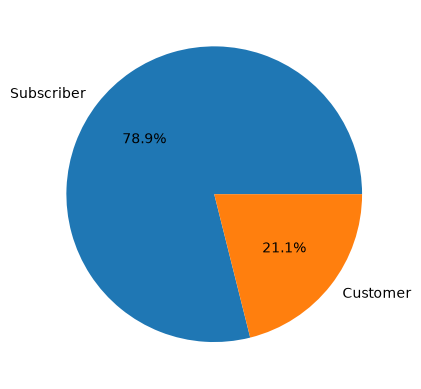

In [23]:
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.show()

Please plot the frequency of each subscription option with a bar chart:

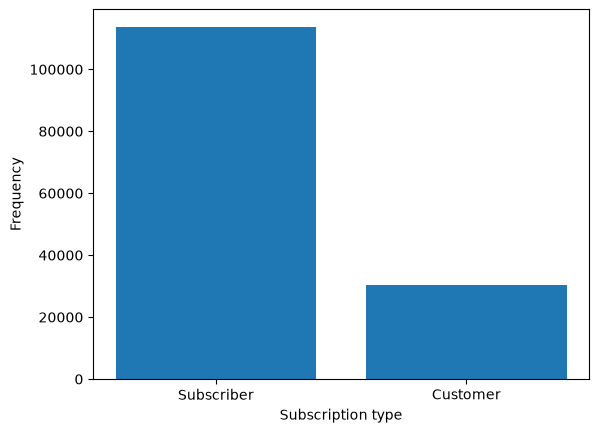

In [24]:
plt.bar(counts.index, counts)
plt.xlabel('Subscription type')
plt.ylabel('Frequency')
plt.show()

Have a look at the start_station column: Which 10 stations occur most frequently?

In [26]:
df['start_station'].value_counts().sort_values(ascending=False).head(10)

start_station
San Francisco Caltrain (Townsend at 4th)         9838
Harry Bridges Plaza (Ferry Building)             7343
Embarcadero at Sansome                           6545
Market at Sansome                                5922
Temporary Transbay Terminal (Howard at Beale)    5113
Market at 4th                                    5030
2nd at Townsend                                  4987
San Francisco Caltrain 2 (330 Townsend)          4976
Steuart at Market                                4913
Townsend at 7th                                  4493
Name: count, dtype: int64

Now look at the end_station column: Which 10 stations occur the least often?

In [27]:
df['end_station'].value_counts().sort_values(ascending=True).head(10)

end_station
Mezes Park                            5
San Jose Government Center           23
Broadway at Main                     56
San Antonio Shopping Center          93
Franklin at Maple                    93
San Mateo County Center             106
Redwood City Public Library         117
Castro Street and El Camino Real    129
Redwood City Medical Center         178
Broadway St at Battery St           205
Name: count, dtype: int64

Create a table that has start_station segmented by subscription_type and include also the row/column margins (subtotals). If you are not sure how to do it, check out the documentation for `pd.crosstab()`.

In [29]:
pd.crosstab(df['start_station'], df['subscription_type'], margins=True)

subscription_type,Customer,Subscriber,All
start_station,,,
2nd at Folsom,427,3349,3776
2nd at South Park,535,3923,4458
2nd at Townsend,882,4105,4987
5th at Howard,606,2029,2635
Adobe on Almaden,75,260,335
...,...,...,...
Townsend at 7th,518,3975,4493
University and Emerson,328,106,434
Washington at Kearney,561,911,1472


Let's look at the duration... Which unit do you think is used here?

How long is the shortest trip? How many are that short?

In [37]:
df['duration'].min()
df[df['duration'] == df['duration'].min()].shape[0]

17

What do you think is going on with the short trips?

In [ ]:
df[df['duration'] == df['duration'].min()]
# invalid measurments - start- and endstation are equivalent

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
2887,8576,60,9/2/2013 9:40,Harry Bridges Plaza (Ferry Building),50,9/2/2013 9:41,Harry Bridges Plaza (Ferry Building),50,354,Subscriber,94102
2925,8651,60,9/2/2013 10:50,San Francisco Caltrain 2 (330 Townsend),69,9/2/2013 10:51,San Francisco Caltrain 2 (330 Townsend),69,544,Subscriber,94107
3535,9444,60,9/3/2013 8:37,Redwood City Public Library,24,9/3/2013 8:38,Redwood City Public Library,24,239,Subscriber,94105
7296,14644,60,9/8/2013 13:55,San Francisco Caltrain (Townsend at 4th),70,9/8/2013 13:56,San Francisco Caltrain (Townsend at 4th),70,521,Subscriber,95126
10457,18792,60,9/12/2013 10:09,Civic Center BART (7th at Market),72,9/12/2013 10:10,Civic Center BART (7th at Market),72,632,Subscriber,94103
11545,20271,60,9/13/2013 12:43,Market at 4th,76,9/13/2013 12:44,Market at 4th,76,500,Subscriber,94116
13437,22689,60,9/15/2013 21:15,Embarcadero at Sansome,60,9/15/2013 21:16,Embarcadero at Sansome,60,577,Subscriber,94111
20568,32159,60,9/23/2013 18:53,Townsend at 7th,65,9/23/2013 18:54,Townsend at 7th,65,566,Subscriber,94107
40000,57581,60,10/14/2013 14:47,Clay at Battery,41,10/14/2013 14:48,Clay at Battery,41,368,Subscriber,94158
55127,77650,60,10/30/2013 18:22,Harry Bridges Plaza (Ferry Building),50,10/30/2013 18:23,Harry Bridges Plaza (Ferry Building),50,416,Subscriber,94110


What is the longest trip?

In [39]:
df[df['duration'] == df['duration'].max()]

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
80510,111309,722236,11/30/2013 13:29,University and Emerson,35,12/8/2013 22:06,University and Emerson,35,247,Customer,94301


How would you define a "long" trip? How many trips are "long" according to your definition?

In [ ]:
df[df['duration'] >= 3*df['duration'].std() + df['duration'].mean()].shape[0]
# definition: larger than the average plus 3 standard deviations
# 847 cases

847

Do the long durations seem reasonable? Why are they so long? What could it tell us about the users?

In [ ]:
# There is not much information about the dataset. I could image, that users forgot to log out, or rented the bikes for several days (took them home). Something like that. Depending on what one want to analyze these trips shouls be labeld as outliers and should be excluded

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
742,4225,21612,8/29/2013 11:18,Powell Street BART,39,8/29/2013 17:18,Market at 10th,67,464,Customer,58553
743,4663,52698,8/29/2013 15:34,Mountain View City Hall,27,8/30/2013 6:12,Park at Olive,38,150,Subscriber,94301
744,4532,84990,8/29/2013 13:43,Market at 4th,76,8/30/2013 13:19,Harry Bridges Plaza (Ferry Building),50,460,Customer,94118
745,4521,85385,8/29/2013 13:37,Market at 4th,76,8/30/2013 13:20,Harry Bridges Plaza (Ferry Building),50,390,Customer,94118
746,5069,86102,8/29/2013 21:41,Embarcadero at Folsom,51,8/30/2013 21:37,Davis at Jackson,42,269,Customer,94111


Plot the duration column.

<Axes: >

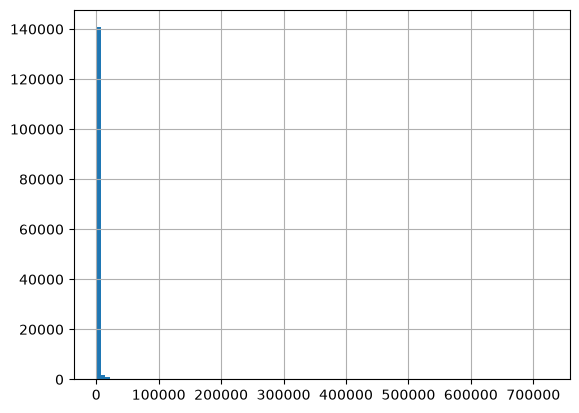

In [56]:
df['duration'].hist(bins= 100)

Does this plot give any insights?

In [ ]:
# There seems to be a group of outliers.

Select subsections of the data to make plots that provide more insights.

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
20535,32121,597517,9/23/2013 18:24,california_ave_caltrain_station,36,9/30/2013 16:23,palo_alto_caltrain_station,34,168,Customer,95051
80510,111309,722236,11/30/2013 13:29,university_and_emerson,35,12/8/2013 22:06,university_and_emerson,35,247,Customer,94301
93400,129504,619322,12/18/2013 9:16,san_jose_diridon_caltrain_station,2,12/25/2013 13:18,sjsu_4th_at_san_carlos,12,653,Subscriber,94041
119830,166010,586356,1/25/2014 20:00,san_antonio_caltrain_station,29,2/1/2014 14:53,san_antonio_caltrain_station,29,693,Customer,94303


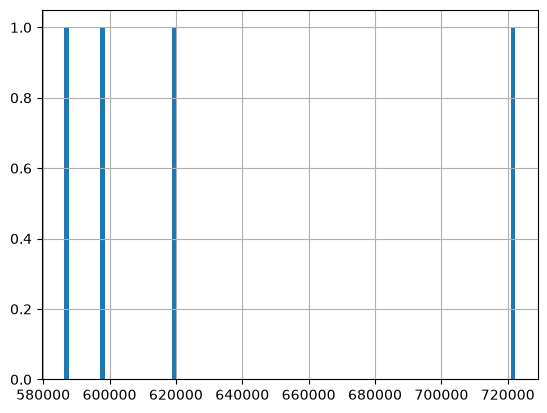

In [ ]:
outlier_df = df[df['duration'] >= 5*df['duration'].std() + df['duration'].mean()]
outlier_df['duration'].hist(bins= 100)

The Product Team would like all of the station names to be lower case and  with `_` as a separator

`South Van Ness at Market` -> `south_van_ness_at_market`  

**DO NOT USE A FOR LOOP. THEY ARE THE 👿**

In [ ]:
df['end_station'] = df['end_station'].str.replace(' ', '_').str.lower()
df['start_station'] = df['start_station'].str.replace(' ', '_').str.lower()

<bound method NDFrame.head of         trip_id  duration       start_date                      start_station  \
0          4576        63  8/29/2013 14:13           south_van_ness_at_market   
1          4607        70  8/29/2013 14:42                 san_jose_city_hall   
2          4130        71  8/29/2013 10:16            mountain_view_city_hall   
3          4251        77  8/29/2013 11:29                 san_jose_city_hall   
4          4299        83  8/29/2013 12:02           south_van_ness_at_market   
...         ...       ...              ...                                ...   
144010   198771       385  2/28/2014 22:15                 powell_street_bart   
144011   198772       145  2/28/2014 22:38           commercial_at_montgomery   
144012   198773       677  2/28/2014 22:45             embarcadero_at_sansome   
144013   198774     64128  2/28/2014 23:01  civic_center_bart_(7th_at_market)   
144014   198775       570  2/28/2014 23:20                  2nd_at_south_park  

Now take a timer and set it to 15 minutes. Take this time to explore the data guided by your own intuition or hypotheses…
> Time boxing is a helpful approach when working with a new dataset so you won't fall into any rabbit holes. 

start_station                             end_station                             
harry_bridges_plaza_(ferry_building)      embarcadero_at_sansome                      1330
townsend_at_7th                           san_francisco_caltrain_(townsend_at_4th)    1322
san_francisco_caltrain_2_(330_townsend)   townsend_at_7th                             1116
market_at_sansome                         2nd_at_south_park                            866
embarcadero_at_sansome                    steuart_at_market                            811
2nd_at_south_park                         market_at_sansome                            798
san_francisco_caltrain_(townsend_at_4th)  harry_bridges_plaza_(ferry_building)         782
2nd_at_townsend                           harry_bridges_plaza_(ferry_building)         757
steuart_at_market                         embarcadero_at_sansome                       717
harry_bridges_plaza_(ferry_building)      2nd_at_townsend                              710
dtype: 

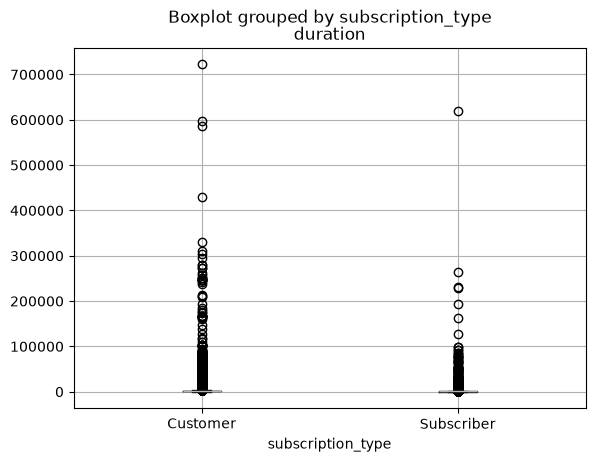

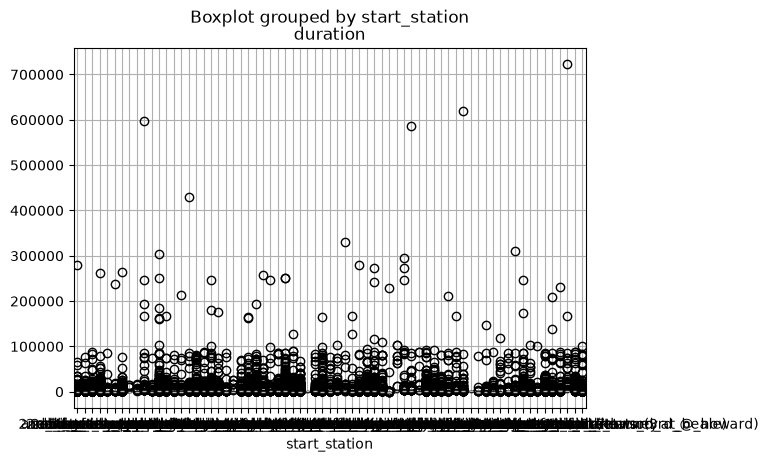

In [ ]:
# Difference in duration depending on subscription type
df.boxplot(column='duration', by='subscription_type')

# Some start and end stations are more used than others
df['start_station'].value_counts().sort_values(ascending=False).head(10)
df['end_station'].value_counts().sort_values(ascending=False).head(10)

# Or specific routes
pd.crosstab(df['start_station'], df['end_station'])
df.groupby(['start_station', 'end_station']).size().sort_values(ascending=False).head(10)
